In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from ISLP.models import (ModelSpec as MS, summarize, poly)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import re

In [2]:
#importing csv as data frame
laptop = pd.read_csv("D:\\Data Analysis\\Laptop Specifications and Price Prediction Dataset\\laptop_data (1).csv")

#viewing dataframe sample
laptop.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [3]:
#cleaning data frame, removing first column that deemed unnecessary
laptop = laptop.drop(laptop.columns[0], axis=1)

#checking data sample again
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [4]:
#checking memory usage
laptop.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   object 
 1   TypeName          1303 non-null   object 
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   object 
 4   Cpu               1303 non-null   object 
 5   Ram               1303 non-null   object 
 6   Memory            1303 non-null   object 
 7   Gpu               1303 non-null   object 
 8   OpSys             1303 non-null   object 
 9   Weight            1303 non-null   object 
 10  Price             1303 non-null   float64
dtypes: float64(2), object(9)
memory usage: 720.4 KB


In [5]:
#checking data type for each collumn
print(laptop.dtypes)

#checking database size
print(laptop.shape)

Company              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                  object
Memory               object
Gpu                  object
OpSys                object
Weight               object
Price               float64
dtype: object
(1303, 11)


In [6]:
#Data Cleaning, preparation for data analysis
#Checking all value of column 'Weight', if there is Kg on the ending of all value remove it.
laptop['Weight'].unique()

array(['1.37kg', '1.34kg', '1.86kg', '1.83kg', '2.1kg', '2.04kg', '1.3kg',
       '1.6kg', '2.2kg', '0.92kg', '1.22kg', '0.98kg', '2.5kg', '1.62kg',
       '1.91kg', '2.3kg', '1.35kg', '1.88kg', '1.89kg', '1.65kg',
       '2.71kg', '1.2kg', '1.44kg', '2.8kg', '2kg', '2.65kg', '2.77kg',
       '3.2kg', '0.69kg', '1.49kg', '2.4kg', '2.13kg', '2.43kg', '1.7kg',
       '1.4kg', '1.8kg', '1.9kg', '3kg', '1.252kg', '2.7kg', '2.02kg',
       '1.63kg', '1.96kg', '1.21kg', '2.45kg', '1.25kg', '1.5kg',
       '2.62kg', '1.38kg', '1.58kg', '1.85kg', '1.23kg', '1.26kg',
       '2.16kg', '2.36kg', '2.05kg', '1.32kg', '1.75kg', '0.97kg',
       '2.9kg', '2.56kg', '1.48kg', '1.74kg', '1.1kg', '1.56kg', '2.03kg',
       '1.05kg', '4.4kg', '1.90kg', '1.29kg', '2.0kg', '1.95kg', '2.06kg',
       '1.12kg', '1.42kg', '3.49kg', '3.35kg', '2.23kg', '4.42kg',
       '2.69kg', '2.37kg', '4.7kg', '3.6kg', '2.08kg', '4.3kg', '1.68kg',
       '1.41kg', '4.14kg', '2.18kg', '2.24kg', '2.67kg', '2.14kg',
       '1.

In [7]:
#removing the last 2 digit from Weight collumn
laptop['Weight'] = laptop['Weight'].str[:-2]

#Changing dtype from object to float
laptop['Weight'] = laptop['Weight'].astype(float)

In [8]:
#Checking to see if it has been fixed
laptop['Weight'].head()

0    1.37
1    1.34
2    1.86
3    1.83
4    1.37
Name: Weight, dtype: float64

In [9]:
#Checking all unique value of Ram Column, to decide how to remove the Gb
laptop['Ram'].unique()

array(['8GB', '16GB', '4GB', '2GB', '12GB', '6GB', '32GB', '24GB', '64GB'],
      dtype=object)

In [10]:
#removing the last 2 digit from Ram collumn
laptop['Ram'] = laptop['Ram'].str[:-2]

#Changing dtype from object to interger
laptop['Ram'] = laptop['Ram'].astype(int)

In [11]:
#re-check
laptop['Ram'].head()

0     8
1     8
2     8
3    16
4     8
Name: Ram, dtype: int64

In [12]:
#Checking OpSys all unique value
laptop['OpSys'].unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux', 'Android',
       'Windows 10 S', 'Chrome OS', 'Windows 7'], dtype=object)

In [13]:
#only need to change the dtype to category
laptop['OpSys'] = laptop['OpSys'].astype('category')

In [14]:
#re-check
laptop['OpSys'].head()

0    macOS
1    macOS
2    No OS
3    macOS
4    macOS
Name: OpSys, dtype: category
Categories (9, object): ['Android', 'Chrome OS', 'Linux', 'Mac OS X', ..., 'Windows 10', 'Windows 10 S', 'Windows 7', 'macOS']

In [15]:
#checking all unique value of memory column
laptop['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [16]:
#Extracting value of the Memory column into a more robust categorical column for analysis

#Creating new column
laptop['Memory_SSD'] = 0
laptop['Memory_HDD'] = 0
laptop['Memory_Hybrid'] = 0
laptop['Memory_Flash'] = 0

for idx, mem in enumerate(laptop['Memory']): #enumerate to spearate the index & value
    matches = re.findall(
        r'(\d+(?:\.\d+)?)\s*(TB|GB)\s*(SSD|HDD|Hybrid|Flash Storage)',
        mem
    ) #first category separating integer and float, second is TB and Gb, last one separating drives type

    for size, unit, drive_type in matches:

        size = float(size)
        if unit == 'TB': #Coverting all TB Values into GB for data unity
            size *= 1024

        if drive_type == 'SSD':
            laptop.loc[idx, 'Memory_SSD'] += size

        elif drive_type == 'HDD':
            laptop.loc[idx, 'Memory_HDD'] += size

        elif drive_type == 'Hybrid':
            laptop.loc[idx, 'Memory_Hybrid'] += size

        elif drive_type == 'Flash Storage':
            laptop.loc[idx, 'Memory_Flash'] += size

In [17]:
#recheck
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Memory_SSD,Memory_HDD,Memory_Hybrid,Memory_Flash
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,128,0,0,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,0,128
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,256,0,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,512,0,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,256,0,0,0


In [18]:
#checking all unique value of GPU column
laptop['Gpu'].unique()

array(['Intel Iris Plus Graphics 640', 'Intel HD Graphics 6000',
       'Intel HD Graphics 620', 'AMD Radeon Pro 455',
       'Intel Iris Plus Graphics 650', 'AMD Radeon R5',
       'Intel Iris Pro Graphics', 'Nvidia GeForce MX150',
       'Intel UHD Graphics 620', 'Intel HD Graphics 520',
       'AMD Radeon Pro 555', 'AMD Radeon R5 M430',
       'Intel HD Graphics 615', 'AMD Radeon Pro 560',
       'Nvidia GeForce 940MX', 'Intel HD Graphics 400',
       'Nvidia GeForce GTX 1050', 'AMD Radeon R2', 'AMD Radeon 530',
       'Nvidia GeForce 930MX', 'Intel HD Graphics',
       'Intel HD Graphics 500', 'Nvidia GeForce 930MX ',
       'Nvidia GeForce GTX 1060', 'Nvidia GeForce 150MX',
       'Intel Iris Graphics 540', 'AMD Radeon RX 580',
       'Nvidia GeForce 920MX', 'AMD Radeon R4 Graphics', 'AMD Radeon 520',
       'Nvidia GeForce GTX 1070', 'Nvidia GeForce GTX 1050 Ti',
       'Nvidia GeForce MX130', 'AMD R4 Graphics',
       'Nvidia GeForce GTX 940MX', 'AMD Radeon RX 560',
       'Nvid

In [19]:
#Extracting value of the GPU column into a more robust categorical column for analysis

#Creating new column to extract Gpu manufacturer
laptop['Gpu_Nvidia'] = laptop['Gpu'].str.contains('Nvidia').astype(int)
laptop['Gpu_AMD'] = laptop['Gpu'].str.contains('AMD').astype(int)
laptop['Gpu_Intel'] = laptop['Gpu'].str.contains('Intel').astype(int)
laptop['Gpu_ARM'] = laptop['Gpu'].str.contains('ARM').astype(int)

In [20]:
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Memory_SSD,Memory_HDD,Memory_Hybrid,Memory_Flash,Gpu_Nvidia,Gpu_AMD,Gpu_Intel,Gpu_ARM
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,128,0,0,0,0,0,1,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,0,128,0,0,1,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,256,0,0,0,0,0,1,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,512,0,0,0,0,1,0,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,256,0,0,0,0,0,1,0


In [21]:
#checking all unique value of CPU column
laptop['Cpu'].unique()

array(['Intel Core i5 2.3GHz', 'Intel Core i5 1.8GHz',
       'Intel Core i5 7200U 2.5GHz', 'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz', 'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
       'Intel Core i5 8250U 1.6GHz', 'Intel Core i3 6006U 2GHz',
       'Intel Core i7 2.8GHz', 'Intel Core M m3 1.2GHz',
       'Intel Core i7 7500U 2.7GHz', 'Intel Core i7 2.9GHz',
       'Intel Core i3 7100U 2.4GHz', 'Intel Atom x5-Z8350 1.44GHz',
       'Intel Core i5 7300HQ 2.5GHz', 'AMD E-Series E2-9000e 1.5GHz',
       'Intel Core i5 1.6GHz', 'Intel Core i7 8650U 1.9GHz',
       'Intel Atom x5-Z8300 1.44GHz', 'AMD E-Series E2-6110 1.5GHz',
       'AMD A6-Series 9220 2.5GHz',
       'Intel Celeron Dual Core N3350 1.1GHz',
       'Intel Core i3 7130U 2.7GHz', 'Intel Core i7 7700HQ 2.8GHz',
       'Intel Core i5 2.0GHz', 'AMD Ryzen 1700 3GHz',
       'Intel Pentium Quad Core N4200 1.1GHz',
       'Intel Atom x5-Z8550 1.44GHz',
       'Intel Celeron Du

In [22]:
#Extracting value of the CPU column into a more robust categorical column for analysis

laptop['Cpu_Intel'] = laptop['Cpu'].str.contains('Intel').astype(int)
laptop['Cpu_AMD'] = laptop['Cpu'].str.contains('AMD').astype(int)
laptop['Cpu_Samsung'] = laptop['Cpu'].str.contains('Samsung').astype(int)

laptop['Cpu_GHz'] = (
    laptop['Cpu']
    .str.extract(r'(\d+(?:\.\d+)?)GHz')
    .astype(float)
)

In [23]:
#re-check
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,Memory_Hybrid,Memory_Flash,Gpu_Nvidia,Gpu_AMD,Gpu_Intel,Gpu_ARM,Cpu_Intel,Cpu_AMD,Cpu_Samsung,Cpu_GHz
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,...,0,0,0,0,1,0,1,0,0,2.3
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,...,0,128,0,0,1,0,1,0,0,1.8
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,...,0,0,0,0,1,0,1,0,0,2.5
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,...,0,0,0,1,0,0,1,0,0,2.7
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,...,0,0,0,0,1,0,1,0,0,3.1


In [24]:
#checking ScreenResolution all unique value
laptop['ScreenResolution'].unique()

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800',
       'IPS Panel Touchscreen 1920x1200', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', 'Touchscreen 2560x1440',
       '1600x900', 'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel 

In [25]:
#Extracting resolution size from ScreenResolution
resolution = laptop['ScreenResolution'].str.extract(
    r'(\d+)x(\d+)'
)

# Inserting screen resolution into the laptop dataframe
laptop['Resolution_Width'] = resolution[0].astype(int)
laptop['Resolution_Height'] = resolution[1].astype(int)
#counting pixel density of the laptop screen
laptop['Pixels'] = (
    laptop['Resolution_Width']
    * laptop['Resolution_Height']
)
#categorizing the screen based on whether its using IPS panel or not
laptop['IPS'] = (
    laptop['ScreenResolution']
    .str.contains('IPS', na=False)
    .astype(int)
)
#categorizing the screen based on whether they are touchscreen or not
laptop['Touchscreen'] = (
    laptop['ScreenResolution']
    .str.contains('Touchscreen', na=False)
    .astype(int)
)

In [26]:
#re-check
laptop.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,...,Gpu_ARM,Cpu_Intel,Cpu_AMD,Cpu_Samsung,Cpu_GHz,Resolution_Width,Resolution_Height,Pixels,IPS,Touchscreen
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,...,0,1,0,0,2.3,2560,1600,4096000,1,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,...,0,1,0,0,1.8,1440,900,1296000,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,...,0,1,0,0,2.5,1920,1080,2073600,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,...,0,1,0,0,2.7,2880,1800,5184000,1,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,...,0,1,0,0,3.1,2560,1600,4096000,1,0


In [27]:
laptop.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price', 'Memory_SSD', 'Memory_HDD',
       'Memory_Hybrid', 'Memory_Flash', 'Gpu_Nvidia', 'Gpu_AMD', 'Gpu_Intel',
       'Gpu_ARM', 'Cpu_Intel', 'Cpu_AMD', 'Cpu_Samsung', 'Cpu_GHz',
       'Resolution_Width', 'Resolution_Height', 'Pixels', 'IPS',
       'Touchscreen'],
      dtype='object')

In [28]:
sub_laptop = laptop[['Company', 'TypeName','OpSys', 'Resolution_Width', 'Resolution_Height', 'Pixels', 'IPS',\
                    'Touchscreen', 'Inches', 'Weight', 'Ram', 'Memory_SSD', 'Memory_HDD',\
                     'Memory_Hybrid', 'Memory_Flash', 'Gpu_Nvidia', 'Gpu_AMD', 'Gpu_Intel', 'Gpu_ARM', 'Cpu_Intel', \
                     'Cpu_AMD', 'Cpu_Samsung', 'Cpu_GHz', 'Price']]

In [29]:
sub_laptop.head()

,Company,TypeName,OpSys,Resolution_Width,Resolution_Height,Pixels,IPS,Touchscreen,Inches,Weight,...,Memory_Flash,Gpu_Nvidia,Gpu_AMD,Gpu_Intel,Gpu_ARM,Cpu_Intel,Cpu_AMD,Cpu_Samsung,Cpu_GHz,Price
0,Apple,Ultrabook,macOS,2560,1600,4096000,1,0,13.3,1.37,...,0,0,0,1,0,1,0,0,2.3,71378.6832
1,Apple,Ultrabook,macOS,1440,900,1296000,0,0,13.3,1.34,...,128,0,0,1,0,1,0,0,1.8,47895.5232
2,HP,Notebook,No OS,1920,1080,2073600,0,0,15.6,1.86,...,0,0,0,1,0,1,0,0,2.5,30636.0000
3,Apple,Ultrabook,macOS,2880,1800,5184000,1,0,15.4,1.83,...,0,0,1,0,0,1,0,0,2.7,135195.3360
4,Apple,Ultrabook,macOS,2560,1600,4096000,1,0,13.3,1.37,...,0,0,0,1,0,1,0,0,3.1,96095.8080


In [30]:
# Checking correlation between variables using correlation matrix and heatmap
# Encode categorical columns
df_encoded = pd.get_dummies(sub_laptop, drop_first=True)
# Compute correlation matrix
corr_matrix = df_encoded.corr()
# Show correlation matrix
print(corr_matrix)

                      Resolution_Width  Resolution_Height    Pixels       IPS  \
Resolution_Width              1.000000           0.994219  0.982492  0.281457   
Resolution_Height             0.994219           1.000000  0.979294  0.289030   
Pixels                        0.982492           0.979294  1.000000  0.245657   
IPS                           0.281457           0.289030  0.245657  1.000000   
Touchscreen                   0.351066           0.357930  0.354820  0.150512   
Inches                       -0.071245          -0.095404 -0.086399 -0.114804   
Weight                       -0.032880          -0.053846 -0.044034  0.016967   
Ram                           0.433121           0.424437  0.396358  0.206623   
Memory_SSD                    0.527708           0.518906  0.486555  0.223014   
Memory_HDD                   -0.123648          -0.135301 -0.114255 -0.093308   
Memory_Hybrid                 0.000253          -0.001440 -0.009563 -0.022551   
Memory_Flash                

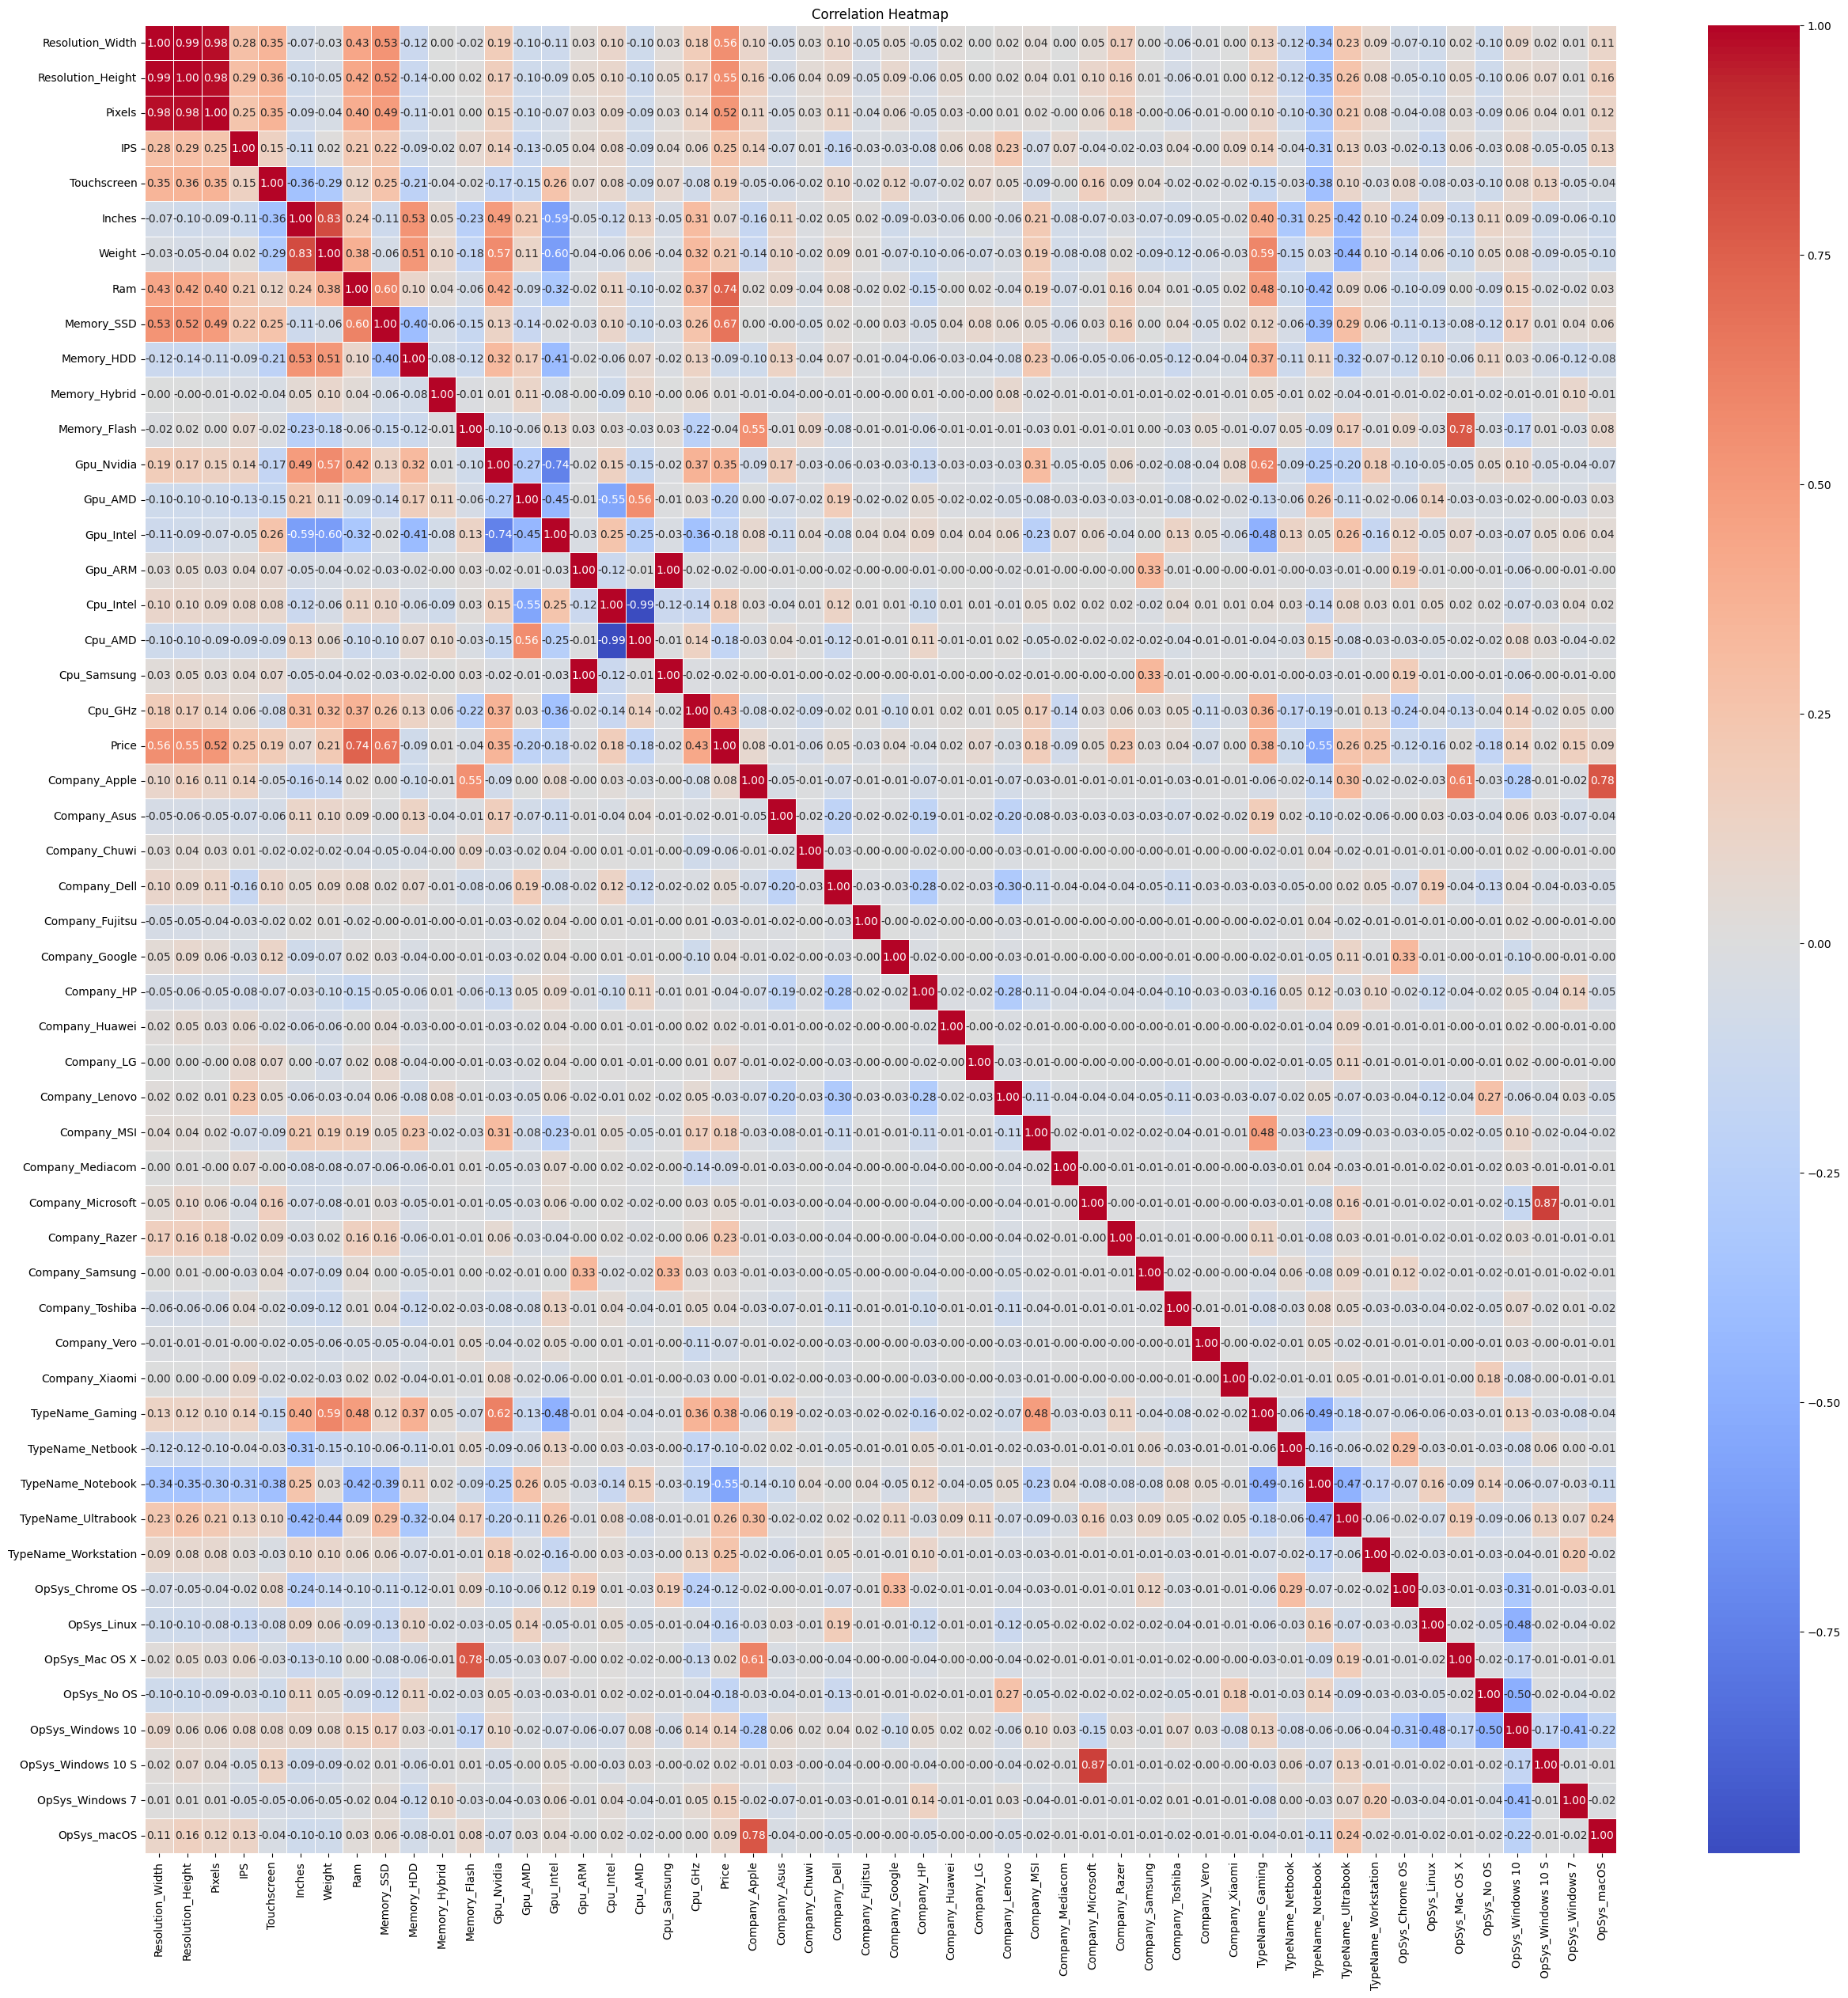

In [31]:
# Create the heatmap
plt.figure(figsize=(30, 30)) # Optional: Adjust figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.savefig('College Correlation Heatmap')
plt.show()

Based on the heatmap, variables that has moderate to strong correlation with price are :
Resolution_Width (0.56), Resolution_Height (0.55), Pixels (0.52), Memory_SSD (0.74), Memory_HDD (0.67), Typename_notebook (-0.55).
Although, variables that correlate with screen are probably in multicollinearity. Thus, its probably better to just include one variable in the modelling to get better result, preferably use pixels. Because pixels could be seen as a summary for the screen width and height column.

In [40]:
#making variables x & y for modelling using MLR (Multiple Linear Regression)
#this time, x variables are gonna consist of variables that highly correlate 
#with price. Based on the heat map above.

X = pd.get_dummies(
    sub_laptop[['Pixels', 'Memory_SSD', 'Memory_HDD', 'TypeName']],
    drop_first=True
)
y = sub_laptop['Price']

#Making model & checking the results summary
X = X.astype(float)
X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     306.9
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          1.65e-292
Time:                        14:14:31   Log-Likelihood:                -14870.
No. Observations:                1303   AIC:                         2.976e+04
Df Residuals:                    1294   BIC:                         2.980e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2.659e+04   2484.468     10.704      0.000    2.17e+04    3.15e+04
Pixels                   0.0049      0.001      9.643      0.000       0.004       0.006
Memory_SSD              98.3976      4.274     23.021      0.000      90.012     106.783
Memory_HDD               6.1675      1.464      4.213      0.000       3.296       9.039
TypeName_Gaming       2.475e+04   2727.222      9.076      0.000    1.94e+04    3.01e+04
TypeName_Netbook     -9450.2670   4903.385     -1.927      0.054   -1.91e+04     169.189
TypeName_Notebook    -8336.7197   2258.877     -3.691      0.000   -1.28e+04   -3905.257
TypeName_Ultrabook    1.072e+04   2542.847      4.217      0.000    5735.277    1.57e+04
TypeName_Workstation  5.327e+04   4539.550     11.734      0.000    4.44e+04    6.22e+04
==============================================================================
Omnibus:                      351.297   Durbin-Watson:                   2.033
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1551.022
Skew:                           1.208   Prob(JB):                         0.00
Kurtosis:                       7.767   Cond. No.                     2.50e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.5e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""